# Building Flood Risk Analysis - South Sudan


In [2]:
# Imports

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum
from IPython.display import display, Markdown
from pprint import pprint
import geopandas as gpd


In [3]:
# Setup Earth Engine

ee.Authenticate()
ee.Initialize()

In [4]:
# Utility functions


def debug_info(debug_object: ee.Image | ee.ImageCollection) -> None:
    """Quickly fetch some key data about the Image or ImageCollection"""

    if isinstance(debug_object, ee.Image):
        pprint(_image_info(debug_object), sort_dicts=False)
    elif isinstance(debug_object, ee.ImageCollection):
        # display(JSON(_image_collection_info(debug_object)), expanded=True)
        pprint(_image_collection_info(debug_object), sort_dicts=False)
    else:
        print("Unsupported type for debug info")


def _image_info(image: ee.Image) -> dict:
    return {
        "bands": image.bandNames().getInfo(),
        "band types": image.bandTypes().getInfo(),
        "crs": image.projection().crs().getInfo(),
        "scale": image.projection().nominalScale().getInfo(),
        "dimensions": image.getInfo()["bands"][0].get("dimensions"),
        "properties": image.toDictionary().getInfo(),
    }


def _image_collection_info(image_collection: ee.ImageCollection) -> dict:
    return {
        "num_images": image_collection.size().getInfo(),
        "bands": (
            image_collection.toList(10)
            .map(lambda img: ee.Image(img).bandNames())
            .getInfo()
        ),
        "band types": (
            image_collection.toList(10)
            .map(lambda img: ee.Image(img).bandTypes())
            .getInfo()
        ),
        "crs": (
            image_collection.toList(10)
            .map(lambda img: ee.Image(img).projection().crs())
            .getInfo()
        ),
        "scale": (
            image_collection.toList(10)
            .map(lambda img: ee.Image(img).projection().nominalScale())
            .getInfo()
        ),
        "properties": (
            image_collection.toList(10)
            .map(lambda img: ee.Image(img).toDictionary())
            .getInfo()
        ),
    }


AOI_OLD_FANGAK = ee.Geometry.BBox(30.877, 9.062, 30.892, 9.074)
AOI_LANKIEN = ee.Geometry.BBox(32.021, 8.489, 32.110, 8.565)


def thumbs(images: list[ee.Image], background_color: str = "white"):
    """Quickly output some thumbnails of data. Image(s) provided must already have gone through vizualise()"""

    background = ee.Image(1).visualize(palette=[background_color])

    composite = ee.ImageCollection([background] + images).mosaic()
    url = composite.getThumbURL({"region": AOI_OLD_FANGAK, "dimensions": 400})
    url2 = composite.getThumbURL({"region": AOI_LANKIEN, "dimensions": 400})
    url3 = composite.clip(south_sudan_simple_geometry).getThumbURL(
        {"region": south_sudan.geometry(), "dimensions": 400}
    )
    _(
        f"[Old Fangak]({url}) | [Lankien]({url2}) | [South Sudan]({url3})<br/>![Old Fangak]({url}) ![Lankien]({url2}) ![South Sudan]({url3})"
    )


def _(markdown: str) -> None:
    """A shortcut to display markdown text"""

    display(Markdown(markdown))


# Data Preperation

## Load Administrative Boundaries and Merge with Population Data

https://developers.google.com/earth-engine/datasets/catalog/WM_geoLab_geoBoundaries_600_ADM0

https://developers.google.com/earth-engine/datasets/catalog/WM_geoLab_geoBoundaries_600_ADM2

In [5]:
south_sudan = (
    ee.FeatureCollection("WM/geoLab/geoBoundaries/600/ADM0")
    .filter(ee.Filter.eq("shapeGroup", "SSD"))
    .first()
)
south_sudan_simple_geometry = south_sudan.geometry().simplify(
    5000
)  # useful for quick filtering of imagecollections
south_sudan_area_km2 = south_sudan.geometry().area().getInfo() / 1e6
_(f"South Sudan Area: {south_sudan_area_km2:.0f} sq km")


South Sudan Area: 645194 sq km

In [6]:
admin2 = (
    ee.FeatureCollection("WM/geoLab/geoBoundaries/600/ADM2")
    .filter(ee.Filter.eq("shapeGroup", "SSD"))
    .select(["shapeName"], [ee.String("Admin2")])
    .map(lambda f: f.set("area", f.geometry().area()))
)

population_csv = pd.read_csv("data/ssd_2023_population_estimates_data.csv")
population_data = population_csv[["Admin1", "Admin2", "Population_2024"]]
admin2 = geemap.ee_join_table(admin2, population_data, "Admin2", "Admin2")

# wia_csv = pd.read_csv("data/wia_scores.csv")
# wia_selected = wia_csv[["ADM2_EN", "Flood impact", "Flood exposure"]]
# admin2 = geemap.ee_join_table(admin2, wia_selected, "Admin2", "ADM2_EN")

_(
    "#### First five rows of admin2 with population data, area and 'WASH Insecurity Analysis' data:"
)
ee.data.computeFeatures({"expression": admin2, "fileFormat": "PANDAS_DATAFRAME"}).head()


#### First five rows of admin2 with population data, area and 'WASH Insecurity Analysis' data:

,geo,Admin1,Admin2,Population_2024,area
0,"{'type': 'Polygon', 'coordinates': [[[30.55958...",Central Equatoria,Morobo,39642,1.292726e+09
1,"{'type': 'Polygon', 'coordinates': [[[31.09764...",Central Equatoria,Kajo-keji,86973,2.582338e+09
2,"{'type': 'Polygon', 'coordinates': [[[30.46250...",Central Equatoria,Lainya,82153,3.461937e+09
3,"{'type': 'Polygon', 'coordinates': [[[29.79858...",Central Equatoria,Yei,181841,6.752714e+09
4,"{'type': 'Polygon', 'coordinates': [[[30.51383...",Central Equatoria,Juba,690920,1.845502e+10


## Google Open Buildings Dataset

https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_Research_open-buildings-temporal_v1

Load and mask so only buildings above the given certainty threshold are included. We use a certainty threshold much lower than the normal google threshold, because this seems to better capture the 'tukuls' of South Sudan.

Note that `buildings` will remain an image collection:
* all images are not the same projection (varies with UTM zones).
* there are images per year. Each image has a `year` property which is a `ee.String`

The data scale is 0.5 metres. To get the total number of buildings in an area need to sum over `building_fractional_count` for a chosen year.

To keep things simple at this point, we will only use 2023 (the most recent year) data, but looking at changes over time is an obvious avenue for further exploration.

In [7]:
BUILDING_THRESHOLD = 0.05

buildings: ee.ImageCollection = (
    ee.ImageCollection("GOOGLE/Research/open-buildings-temporal/v1")
    .filterBounds(south_sudan.geometry())
    .map(
        lambda img: img.set(
            "year", ee.Date(img.get("system:time_start")).format(ee.String("YYYY"))
        )
    )
    .filter(ee.Filter.eq("year", "2023"))
    .map(
        lambda img: img.updateMask(
            img.select("building_presence").gt(BUILDING_THRESHOLD)
        )
    )
    .select("building_fractional_count")
)
# debug_info(buildings)

#### Downscaling Open Buildings
It is possible to downsample the buildings dataset as 0.5 metres is unnecessarily precise for future calculations. Downsampling to 4 metres is a 64 times reduction in size. Note that this is different from the automatic pyramiding that GEE does, as GEE uses nearest neighbour, wheras for this operation we want sum.

However, doing the downsampling itself uses a lot of compute (39 hours of EECU per image) and storage, and I've run out of GEE credit.

In [8]:
DO_SAMPLING = False
BUILDINGS_ASSET_ID = "projects/earthengine-experiment/assets/open_buildings_4m"

# Setup the downsampling
buildings_downsampled = buildings.map(
    lambda img: (
        img.reduceResolution(reducer=ee.Reducer.sum())
        .reproject(crs=img.projection(), scale=4)
        .toFloat()
    )
)

# Do the downsampling - VERY slow
if DO_SAMPLING:
    for i in [1]:  # range(buildings_downsampled.size().getInfo()):
        img = ee.Image(
            buildings_downsampled.toList(buildings_downsampled.size()).get(i)
        )

        task = ee.batch.Export.image.toAsset(
            image=img,
            description=img.id().getInfo(),
            assetId=f"{BUILDINGS_ASSET_ID}/{img.id().getInfo()}",
            scale=4,
            region=img.geometry(),
            maxPixels=1e13,
        )
        task.start()

# Now reload the downsampled data as a new ImageCollection
buildings2 = ee.ImageCollection(
    "projects/earthengine-experiment/assets/open_buildings_4m"
)
# debug_info(buildings2)

## JRC Flood Hazard Dataset

https://developers.google.com/earth-engine/datasets/catalog/JRC_CEMS_GLOFAS_FloodHazard_v2_1

We use pre-calculated JRC flood hazard data available on GE.

- This an image collection, where images cover different geographical area (4 to cover all South Sudan)
- The data is produced with return period of 10, 20, 50, 75, 100, 200 and 500 years. Given that this is for humanitarian analysis rather than long-term infrastructure construction, we will only consider 10, 20 and 50 years.
- The data gives the depth of the flood at given return period. We simplify this by making a binary mask of flooding. Any depth over `DEPTH_THRESHOLD` is considered flooded.

We finish with images with 3 binary bands, `RP10`, `RP20`, `RP50` and one combined band `RPcombined` which is the sum of these three bands - an integer between 1 and 3.

All of the original images are EPSG:4326 with a native resolution ~90m. Therefore can mosaic this without projection problems.

In [9]:
DEPTH_THRESHOLD = 0

flood_hazard_collection: ee.ImageCollection = (
    ee.ImageCollection("JRC/CEMS_GLOFAS/FloodHazard/v2_1")
    .filterBounds(south_sudan.geometry())
    .select(["RP10_depth", "RP20_depth", "RP50_depth"])
    .map(lambda img: img.rename(["RP10", "RP20", "RP50"]))
    .map(lambda img: img.gt(DEPTH_THRESHOLD))
    .map(
        lambda img: img.addBands(
            img.reduce(ee.Reducer.sum()).unitScale(0, 3).rename("RPcombined")
        )
    )
)

flood_hazard_image: ee.Image = flood_hazard_collection.mosaic().setDefaultProjection(
    flood_hazard_collection.first().projection()
)

# debug_info(flood_hazard_image)

## JRC Surface Water

https://developers.google.com/earth-engine/datasets/catalog/JRC_GSW1_4_GlobalSurfaceWater

A worldwide image in EPSG 4326 with ~30m scale derived from Landsat 5, 7 and 8. The original dataset duplicates the data by also using it as a mask, so we have to fix this. 

For our analysis we want a binary image of 'normal' water locations.  To do this we consider anywhere where there is water at least 50% of the time.

We finish with one worldwide image where normal water locations are 1, and everything else is 0.



In [10]:
OCCURRENCE_THRESHOLD = 50  # percent

normally_water: ee.Image = (
    ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
    .select("occurrence")
    .unmask(0)
    .mask(ee.Image(1))
    .gt(OCCURRENCE_THRESHOLD)
    .rename("normally_water")
)
# debug_info(permenant_water)
# thumbs([permenant_water.visualize(palette=["blue"])])

## Sentinel 1 Data

https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S1_GRD

In [11]:
# Import and  initial filters on sentinel-1 data

s1: ee.ImageCollection = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(south_sudan_simple_geometry)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING"))
    .filter(ee.Filter.eq("transmitterReceiverPolarisation", ["VV", "VH"]))
    .select(["VV", "VH"])
)
_(f"{s1.size().getInfo()} Sentinel-1 images selected")

9714 Sentinel-1 images selected

# Water Extent Determination

### Prepare Histograms of Sentinel-1 data

In [12]:
# Sample data for in order to produce a histogram to determine threshold for water vs non-water classification


def sample_s1(month_start: int, month_end: int | None = None):
    return (
        s1.filter(ee.Filter.calendarRange(2025, 2025, field="year"))
        .filter(ee.Filter.calendarRange(month_start, month_end, field="month"))
        .median()
        .addBands(normally_water.toInt())
        .stratifiedSample(
            region=south_sudan_simple_geometry,
            classBand="normally_water",
            numPoints=1000,
            scale=100,
        )
    )


sample_dry_df = ee.data.computeFeatures(
    {"expression": sample_s1(2, 3), "fileFormat": "PANDAS_DATAFRAME"}
)
sample_wet_df = ee.data.computeFeatures(
    {"expression": sample_s1(9, 10), "fileFormat": "PANDAS_DATAFRAME"}
)


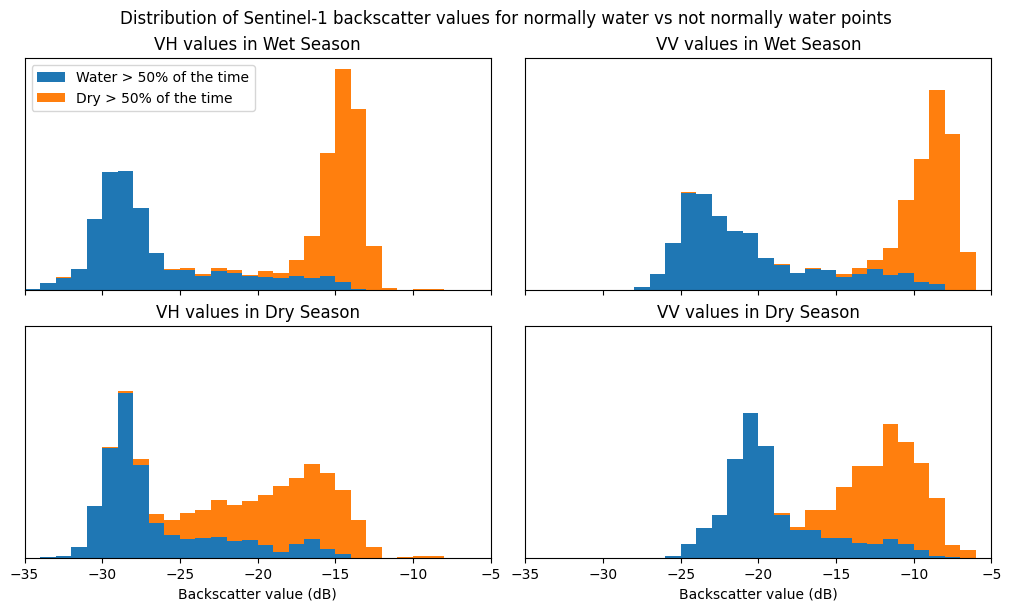

In [13]:
# Plot the histograms


def plot_histogram(axes: plt.Axes, sample_df: pd.DataFrame, band: str, month_name: str):
    axes.hist(
        (
            sample_df[band][sample_df["normally_water"] == 1],
            sample_df[band][sample_df["normally_water"] == 0],
        ),
        bins=range(-35, -5),
        density=True,
        label=["Water > 50% of the time", "Dry > 50% of the time"],
        histtype="barstacked",
    )
    axes.set_xlim(-35, -5)
    axes.set_yticks([])
    axes.set_title(f"{band} values in {month_name}")


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2, figsize=(10, 6), layout="constrained", sharex="col", sharey="all"
)
fig.suptitle(
    "Distribution of Sentinel-1 backscatter values for normally water vs not normally water points"
)
plot_histogram(ax1, sample_wet_df, "VH", "Wet Season")
plot_histogram(ax3, sample_dry_df, "VH", "Dry Season")
plot_histogram(ax2, sample_wet_df, "VV", "Wet Season")
plot_histogram(ax4, sample_dry_df, "VV", "Dry Season")
ax1.legend()
ax3.set_xlabel("Backscatter value (dB)")
ax4.set_xlabel("Backscatter value (dB)");


### Determine Wet Season Water Extent per Year 

In [ ]:
TRANSMITTER_RECEIVER_POLARISATION = "VH"
BACKSCATTER_THRESHOLD = -20

_wet_season_filter = ee.Filter.calendarRange(9, 10, field="month")

wet_season_minimum_s1 = ee.ImageCollection(
    s1.filter(_wet_season_filter)
    .map(lambda img: img.set("year", img.date().get("year")))
    .aggregate_array("year")
    .distinct()
    .map(
        lambda year: (
            s1.filter(ee.Filter.calendarRange(ee.Number(year), field="year"))
            .filter(_wet_season_filter)
            .median()
            .set("system:index", ee.String(year))
        )
    )
)

wet_season_water_extent = wet_season_minimum_s1.select(
    TRANSMITTER_RECEIVER_POLARISATION
).map(lambda img: img.lt(BACKSCATTER_THRESHOLD).rename("water").copyProperties(img))

# thumbs([wet_season_water_extent.filter(ee.Filter.inList("YYYY", ["2016","2024", "2025"])).toBands().visualize(min=0,max=1)])

### Determine the Wet Season Water Area per Year

Mean is used and then scaled to the country (as opposed to sum), as in some years there are coverage gaps.

In [15]:
fraction_of_country_wet_season_water: dict[str, float] = (
    wet_season_water_extent.toBands()
    .reduceRegion(
        reducer=ee.Reducer.mean(), geometry=south_sudan_simple_geometry, scale=1000
    )
    .getInfo()
)

display(fraction_of_country_wet_season_water)


{'2016_water': 0.006142536812748081,
 '2017_water': 0.004478857495508883,
 '2018_water': 0.0087736231391307,
 '2019_water': 0.0036811304890922354,
 '2020_water': 0.006287909608194179,
 '2021_water': 0.01159817923727552,
 '2022_water': 0.02065427434222926,
 '2023_water': 0.016783861284423534,
 '2024_water': 0.019691683176747438,
 '2025_water': 0.01806967483611779}

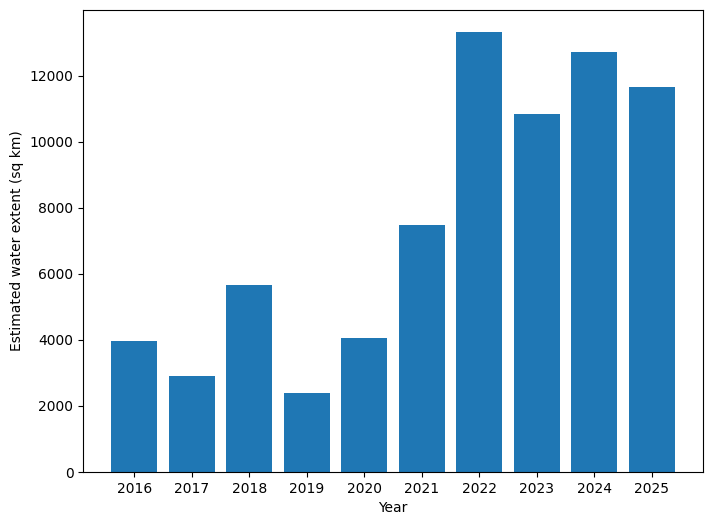

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(
    [key[0:4] for key in fraction_of_country_wet_season_water.keys()],
    [
        mean * south_sudan_area_km2
        for mean in fraction_of_country_wet_season_water.values()
    ],
)
ax.set_xlabel("Year")
ax.set_ylabel("Estimated water extent (sq km)");

In [17]:
water_per_payam = (
    wet_season_water_extent.toBands()
    .multiply(ee.Image.pixelArea())
    .divide(1e6)
    .reduceRegions(reducer=ee.Reducer.sum(), collection=admin2, scale=1000)
)
water_per_payam_gdf: gpd.GeoDataFrame = ee.data.computeFeatures(
    {
        "expression": water_per_payam,
        "fileFormat": "GEOPANDAS_GEODATAFRAME",
    }
)
water_per_payam_gdf.head(3)

,geometry,2016_water,2017_water,2018_water,2019_water,2020_water,2021_water,2022_water,2023_water,2024_water,2025_water,Admin1,Admin2,Population_2024,area
0,"POLYGON ((30.55958 3.62384, 30.55965 3.6238, 3...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Central Equatoria,Morobo,39642,1.292726e+09
1,"POLYGON ((31.09764 3.97353, 31.14626 3.7758, 3...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Central Equatoria,Kajo-keji,86973,2.582338e+09
2,"POLYGON ((30.46251 4.52642, 30.51506 4.46473, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Central Equatoria,Lainya,82153,3.461937e+09


/var/folders/6y/6wv1ttts1pj87ndj6lqxrjhm0000gn/T/ipykernel_41836/287225299.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.1, 1, 1]);


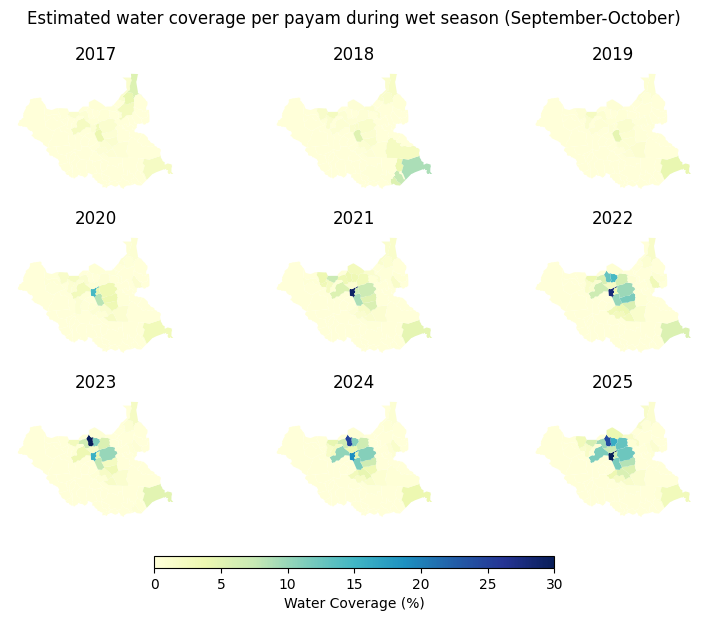

In [18]:
fig, ax = plt.subplots(3, 3, figsize=(8, 6))

for i, year in enumerate(range(2017, 2026)):
    perc_water_coverage = (
        water_per_payam_gdf[f"{year}_water"] / (water_per_payam_gdf["area"] / 1e6)
    ) * 100

    this_ax = ax[i // 3, i % 3]
    water_per_payam_gdf.assign(perc_water_coverage=perc_water_coverage).plot(
        ax=this_ax,
        column="perc_water_coverage",
        cmap="YlGnBu",
        legend=False,
        vmin=0,
        vmax=30,
    )
    this_ax.set_title(year)
    this_ax.set_axis_off()

fig.suptitle("Estimated water coverage per payam during wet season (September-October)")
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
fig.colorbar(
    ax[0][0].collections[0],
    cax=cbar_ax,
    orientation="horizontal",
    label="Water Coverage (%)",
)
fig.tight_layout(rect=[0, 0.1, 1, 1]);


In [19]:
flooded_buildings_per_payam = (
    wet_season_water_extent.toBands()
    .multiply(buildings.mosaic())
    .multiply(ee.Image.pixelArea())
    .multiply(4)
    .reduceRegions(reducer=ee.Reducer.sum(), collection=admin2, scale=64)
)
flooded_buildings_per_payam_gdf: gpd.GeoDataFrame = ee.data.computeFeatures(
    {
        "expression": flooded_buildings_per_payam,
        "fileFormat": "GEOPANDAS_GEODATAFRAME",
    }
)
flooded_buildings_per_payam_gdf.head(3)

,geometry,2016_water,2017_water,2018_water,2019_water,2020_water,2021_water,2022_water,2023_water,2024_water,2025_water,Admin1,Admin2,Population_2024,area
0,"POLYGON ((30.55958 3.62384, 30.55965 3.6238, 3...",0.0,0.0,0.0,0.0,0.0,0.0,22.095817,0.000000,0.000000,0.000000,Central Equatoria,Morobo,39642,1.292726e+09
1,"POLYGON ((31.09764 3.97353, 31.14626 3.7758, 3...",0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Central Equatoria,Kajo-keji,86973,2.582338e+09
2,"POLYGON ((30.46251 4.52642, 30.51506 4.46473, ...",0.0,0.0,0.0,0.0,0.0,0.0,14.736052,30.563906,30.563906,41.312499,Central Equatoria,Lainya,82153,3.461937e+09


/var/folders/6y/6wv1ttts1pj87ndj6lqxrjhm0000gn/T/ipykernel_41836/1924078816.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.1, 1, 1]);


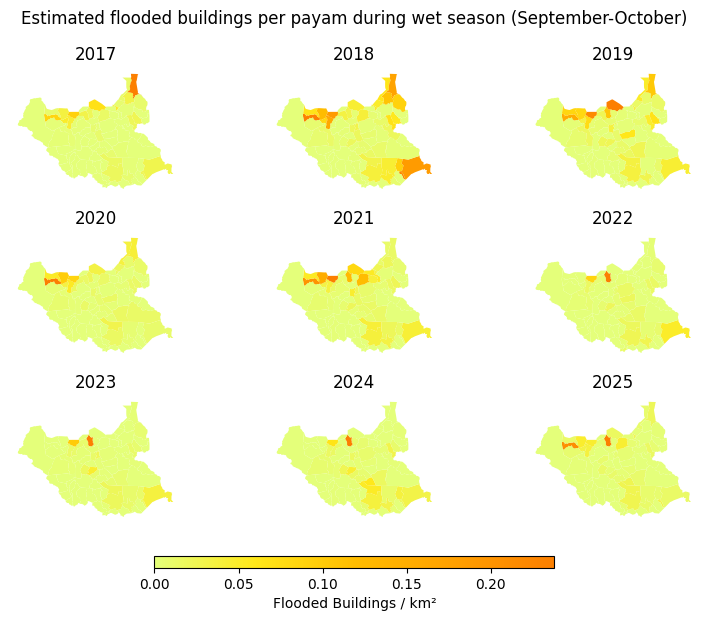

In [20]:
fig, ax = plt.subplots(3, 3, figsize=(8, 6))

for i, year in enumerate(range(2017, 2026)):
    this_ax = ax[i // 3, i % 3]
    flooded_buildings_per_payam_gdf.assign(
        buildings_km=flooded_buildings_per_payam_gdf[f"{year}_water"]
        / flooded_buildings_per_payam_gdf["area"]
        * 1e6
    ).plot(
        ax=this_ax,
        column="buildings_km",
        cmap="Wistia",
        legend=False,
    )
    this_ax.set_title(year)
    this_ax.set_axis_off()

fig.suptitle(
    "Estimated flooded buildings per payam during wet season (September-October)"
)
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])  # [left, bottom, width, height]
fig.colorbar(
    ax[0][0].collections[0],
    cax=cbar_ax,
    orientation="horizontal",
    label="Flooded Buildings / km²",
)
fig.tight_layout(rect=[0, 0.1, 1, 1]);


# Flood Hazard Visualisations

In [21]:
buildings_risk = (
    buildings.filter(ee.Filter.eq("year", "2023"))
    .mosaic()
    .gt(0)
    .selfMask()
    .multiply(flood_hazard_image.select("RPcombined").unmask(0))
)
flood_risk = ee.Image(1).updateMask(flood_hazard_image.select("RPcombined"))

flood_vis = {"palette": ["aqua"], "opacity": 0.5}
buildings_vis = {"palette": ["black", "yellow", "orange", "red"]}

thumbs([flood_risk.visualize(**flood_vis), buildings_risk.visualize(**buildings_vis)])

map: geemap.Map = geemap.Map(basemap="ROADMAP")
map.centerObject(AOI_OLD_FANGAK)
map.addLayer(flood_risk, flood_vis, "Flood risk")
map.addLayer(buildings_risk, buildings_vis, "Buildings at risk")

map

[Old Fangak](https://earthengine.googleapis.com/v1/projects/earthengine-experiment/thumbnails/604fd3eb89f8dc03b4095c3fff0a058c-42f4343b326fe1fc307156cc4485382e:getPixels) | [Lankien](https://earthengine.googleapis.com/v1/projects/earthengine-experiment/thumbnails/fbac20dadf099a17f002e7cea45ace59-079ae47192307c661944e33540bde802:getPixels) | [South Sudan](https://earthengine.googleapis.com/v1/projects/earthengine-experiment/thumbnails/cfe5b3f521ff6b01ca8b15c518b96471-7c26589667c0b123a04082c1466c3e0a:getPixels)<br/>![Old Fangak](https://earthengine.googleapis.com/v1/projects/earthengine-experiment/thumbnails/604fd3eb89f8dc03b4095c3fff0a058c-42f4343b326fe1fc307156cc4485382e:getPixels) ![Lankien](https://earthengine.googleapis.com/v1/projects/earthengine-experiment/thumbnails/fbac20dadf099a17f002e7cea45ace59-079ae47192307c661944e33540bde802:getPixels) ![South Sudan](https://earthengine.googleapis.com/v1/projects/earthengine-experiment/thumbnails/cfe5b3f521ff6b01ca8b15c518b96471-7c26589667c0b123a04082c1466c3e0a:getPixels)

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

# Flood Hazard Calculations

In [22]:
payams_with_area_flooded = (
    flood_hazard_image.select("RP50")
    .rename(["area_flooded"])
    .multiply(ee.Image.pixelArea())
    .reduceRegions(reducer=ee.Reducer.sum(), collection=admin2)
    .map(lambda f: f.set("area_flooded", f.get("sum")).set("sum", None))
)


def payams_with_area_flooded_and_num_buildings(scale: int):
    return (
        buildings.filter(ee.Filter.eq("year", "2023"))
        .map(
            lambda img: img.addBands(img.multiply(flood_hazard_image.select("RP50")))
        )  # Only do it for RP50 to keep things speedy
        .mosaic()
        .rename(["all_buildings", "RP50"])
        .multiply(ee.Image().pixelArea())
        .multiply(
            4
        )  # Original buildings dataset is franctional_area per 0.5x0.5m pixel - > convert to 1x1m
        .reduceRegions(
            reducer=ee.Reducer.sum(), collection=payams_with_area_flooded, scale=scale
        )
    )


def post_process_df(df: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    return df.assign(
        percentage_at_risk=df["RP50"] / df["all_buildings"] * 100,
        pop_at_risk=df["Population_2024"] * df["RP50"] / df["all_buildings"],
        percentage_area_flooded=df["area_flooded"] / df["area"] * 100,
    )


ASSET_ID = "users/angusmcb/payams_with_building_flood_risk"


class DoWhat(Enum):
    QUICK_CALC = 1
    EXPORT = 2
    LOAD_EXISTING = 3


do_what = DoWhat.LOAD_EXISTING

raw_df: gpd.GeoDataFrame | None = None

match do_what:
    case DoWhat.QUICK_CALC:
        raw_df = ee.data.computeFeatures(
            {
                "expression": payams_with_area_flooded_and_num_buildings(128),
                "fileFormat": "GEOPANDAS_GEODATAFRAME",
            }
        )

    case DoWhat.EXPORT:
        task = ee.batch.Export.table.toAsset(
            collection=payams_with_area_flooded_and_num_buildings(4),
            description="calculating_buildings_at_risk",
            assetId=ASSET_ID,
            overwrite=True,
        )
        task.start()

    case DoWhat.LOAD_EXISTING:
        raw_df = ee.data.computeFeatures(
            {
                "expression": ee.FeatureCollection(ASSET_ID),
                "fileFormat": "GEOPANDAS_GEODATAFRAME",
            }
        )

if raw_df is not None:
    df = post_process_df(raw_df)

    display(df.head(2))


,geometry,Admin1,Admin2,Flood exposure,Flood impact,Population_2024,RP50,all_buildings,area,area_flooded,percentage_at_risk,pop_at_risk,percentage_area_flooded
0,"POLYGON ((31.09764 3.97353, 31.14626 3.7758, 3...",Central Equatoria,Kajo-keji,0,0,86973,9.628412,15754.676669,2.582338e+09,2.816864e+07,0.061115,53.153226,1.090819
1,"POLYGON ((33.44316 4.78454, 33.45497 4.6516, 3...",Eastern Equatoria,Kapoeta South,0,0,67827,179.174871,14573.164163,1.248073e+09,1.304916e+07,1.229485,833.922809,1.045545


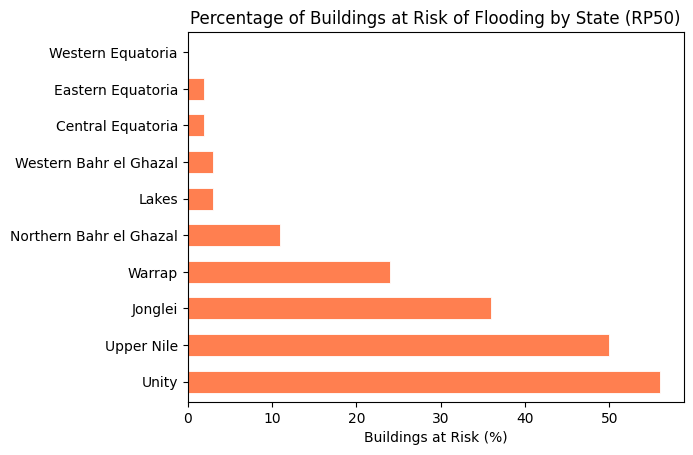

In [23]:
# Group by Admin1, sum numeric columns only, then recompute percentage
admin1_summary = (
    df.groupby("Admin1")[["all_buildings", "RP50", "Population_2024"]]
    .sum()
    .assign(percentage_at_risk=lambda d: d["RP50"] / d["all_buildings"] * 100)
    .sort_values("percentage_at_risk", ascending=False)
    .round(0)
    .reset_index()[["Admin1", "percentage_at_risk"]]
    .rename(columns={"Admin1": "State", "percentage_at_risk": "Buildings at Risk (%)"})
)

admin1_summary.set_index("State").plot(
    kind="barh",
    legend=False,
    color="coral",
    edgecolor="white",
    linewidth=0.6,
    width=0.6,
    title="Percentage of Buildings at Risk of Flooding by State (RP50)",
    ylabel="",
    xlabel="Buildings at Risk (%)",
    rot=0,
)
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

Overall percentage of buildings at risk: 15.8%

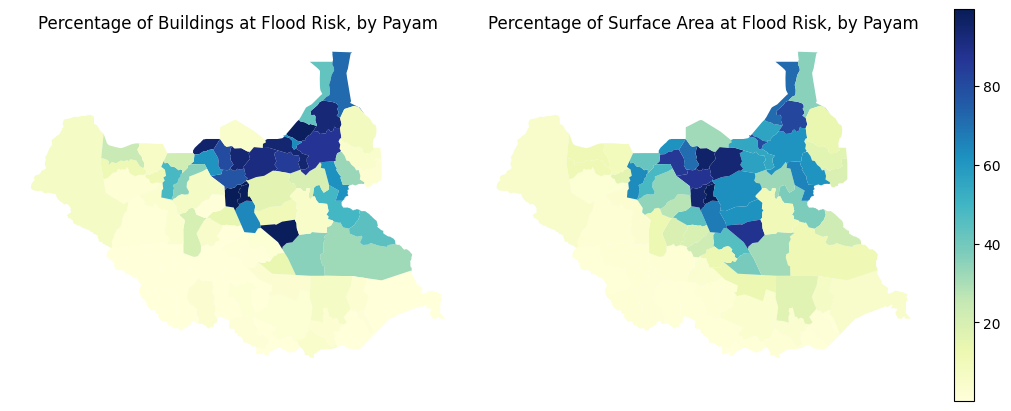

In [24]:
total_buildings = df["all_buildings"].sum()
total_at_risk = df["RP50"].sum()
overall_percentage_at_risk = (total_at_risk / total_buildings) * 100
_(f"Overall percentage of buildings at risk: {overall_percentage_at_risk:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

df.plot(ax=ax1, column="percentage_at_risk", cmap="YlGnBu")
ax1.set_title("Percentage of Buildings at Flood Risk, by Payam")
ax1.set_axis_off()

df.plot(ax=ax2, column="percentage_area_flooded", legend=True, cmap="YlGnBu")
ax2.set_title("Percentage of Surface Area at Flood Risk, by Payam")
ax2.set_axis_off();


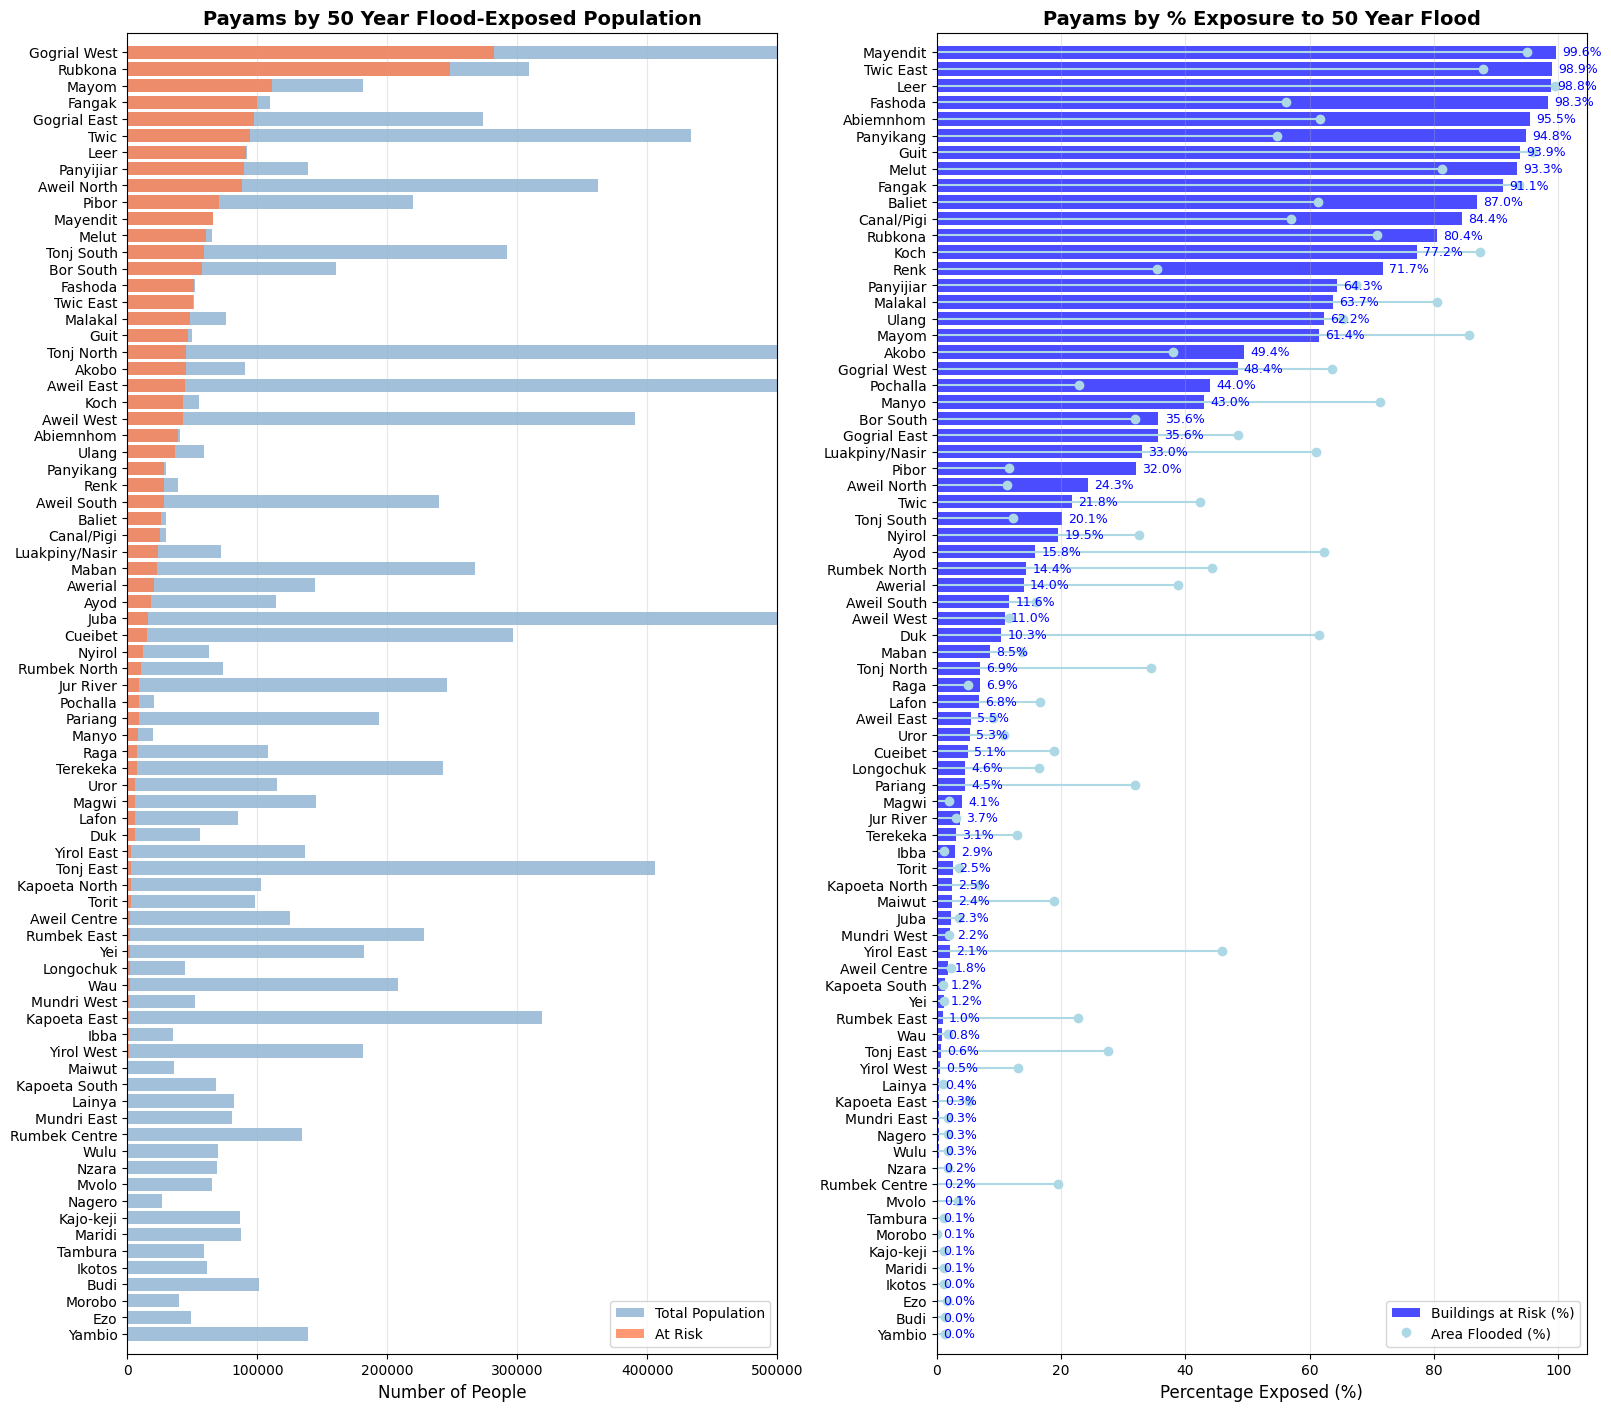

In [25]:
ax1: plt.Axes
ax2: plt.Axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 14), layout="constrained")

# Bar chart - Absolute numbers
ordered_by_pop_at_risk = df.sort_values("pop_at_risk", ascending=False)
x_pos = range(len(ordered_by_pop_at_risk))
ax1.set_ymargin(0.01)

ax1.barh(
    x_pos,
    ordered_by_pop_at_risk["Population_2024"],
    alpha=0.5,
    label="Total Population",
    color="steelblue",
)
ax1.barh(
    x_pos,
    ordered_by_pop_at_risk["pop_at_risk"],
    alpha=0.8,
    label="At Risk",
    color="coral",
)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(ordered_by_pop_at_risk["Admin2"])

ax1.invert_yaxis()
ax1.set_xlabel("Number of People", fontsize=12)
ax1.set_xlim(0, 500000)
# ax1.set_xscale("log")

ax1.set_title(
    "Payams by 50 Year Flood-Exposed Population",
    fontsize=14,
    fontweight="bold",
)
ax1.legend()
ax1.grid(False)
ax1.grid(axis="x", alpha=0.3)

# Percentage chart
ordered_by_pct = df.sort_values("percentage_at_risk")

bars = ax2.barh(
    ordered_by_pct["Admin2"],
    ordered_by_pct["percentage_at_risk"],
    color="blue",
    alpha=0.7,
    label="Buildings at Risk (%)",
)
area_bars = ax2.stem(
    ordered_by_pct["percentage_area_flooded"],
    linefmt="lightblue",
    basefmt=" ",
    orientation="horizontal",
    label="Area Flooded (%)",
)
ax2.set_xlabel("Percentage Exposed (%)", fontsize=12)
ax2.set_title("Payams by % Exposure to 50 Year Flood", fontsize=14, fontweight="bold")
ax2.legend()
ax2.set_ymargin(0.01)
ax2.grid(False)
ax2.grid(axis="x", alpha=0.3)
# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, ordered_by_pct["percentage_at_risk"])):
    ax2.text(
        val + 1,
        i,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
        color="blue",
    )


## Check buildings vs population

This is very off for Juba, but that is potentially easy to explain by informal migration to Juba

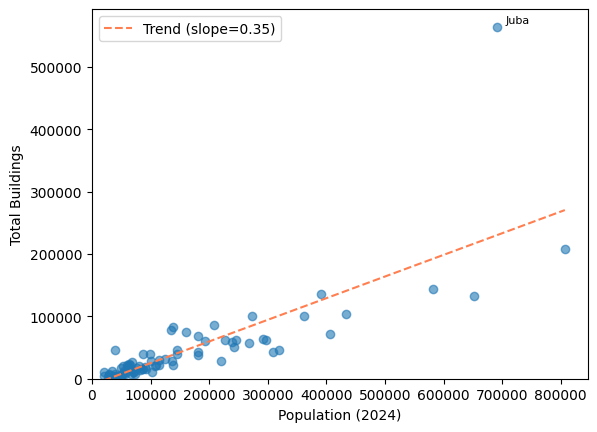

In [26]:
fig, ax = plt.subplots()

ax.scatter(df["Population_2024"], df["all_buildings"], alpha=0.6)

# Trend line
m, b = np.polyfit(df["Population_2024"], df["all_buildings"], 1)
x = np.linspace(df["Population_2024"].min(), df["Population_2024"].max(), 200)
ax.plot(
    x,
    m * x + b,
    color="coral",
    linewidth=1.5,
    linestyle="--",
    label=f"Trend (slope={m:.2f})",
)
ax.legend()

for i, row in df.nlargest(1, "all_buildings").iterrows():
    ax.annotate(
        row["Admin2"],
        xy=(row["Population_2024"], row["all_buildings"]),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=8,
    )

ax.set(xlabel="Population (2024)", ylabel="Total Buildings")

ax.set_xbound(lower=0)
ax.set_ybound(lower=0);
